<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-07-06 07:40:26--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  45.9MB/s    in 3.4s    

2026-07-06 07:40:31 (44.7 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 167.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 170.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 155.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 145.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 150.6 MB/s eta 0:00:00


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [23]:
Query = """
SELECT CompTotal as Total_Compensation FROM main
"""
df = pd.read_sql_query(Query, conn)
print(df['Total_Compensation'].head(15))

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
Name: Total_Compensation, dtype: float64


In [25]:
df = df.copy()
mean = df['Total_Compensation'].mean()
df['Total_Compensation'] = df['Total_Compensation'].fillna(mean)
df['Total_Compensation'].isna().sum()

np.int64(0)

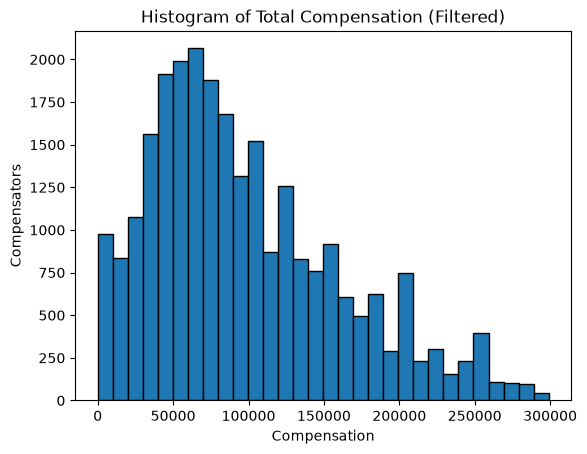

In [31]:
## Write your code here
filtered_df = df[df['Total_Compensation'] < 300000]

filtered_df['Total_Compensation'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('Histogram of Total Compensation (Filtered)')
plt.ylabel('Compensators')
plt.xlabel('Compensation')
plt.show()

**Box Plots**

Plot a box plot of Age.


In [32]:
## Write your code here
Query = """
SELECT Age FROM main
"""
df = pd.read_sql_query(Query, conn)
print(df['Age'].head(15))

0     Under 18 years old
1        35-44 years old
2        45-54 years old
3        18-24 years old
4        18-24 years old
5     Under 18 years old
6        35-44 years old
7        18-24 years old
8        45-54 years old
9        35-44 years old
10       35-44 years old
11       45-54 years old
12       35-44 years old
13       35-44 years old
14       25-34 years old
Name: Age, dtype: str


In [36]:
df = df.copy()
mode = df['Age'].mode()[0]
df['Age'] = df['Age'].fillna(mode)

# Extract the first set of digits from the text string
df['Age_Numeric'] = df['Age'].str.extract(r'(\d+)').astype(float)

# Handle the 'Under 18' category manually since its digit is 18, but it means younger
df.loc[df['Age'] == 'Under 18 years old', 'Age_Numeric'] = 16 

print(df[['Age', 'Age_Numeric']].head())


                  Age  Age_Numeric
0  Under 18 years old         16.0
1     35-44 years old         35.0
2     45-54 years old         45.0
3     18-24 years old         18.0
4     18-24 years old         18.0


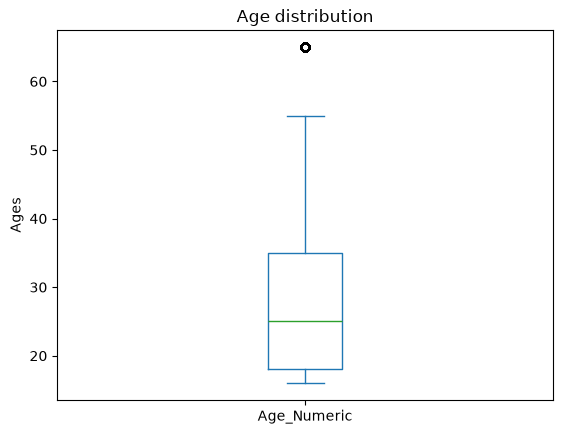

In [37]:
df['Age_Numeric'].plot(kind='box')
plt.title('Age distribution')
plt.ylabel('Ages')
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


In [39]:
## Write your code here
Query = """
SELECT Age, WorkExp FROM main
"""
df = pd.read_sql_query(Query, conn)
print(df[['Age', 'WorkExp']].head(15))

                   Age  WorkExp
0   Under 18 years old      NaN
1      35-44 years old     17.0
2      45-54 years old      NaN
3      18-24 years old      NaN
4      18-24 years old      NaN
5   Under 18 years old      NaN
6      35-44 years old      NaN
7      18-24 years old      NaN
8      45-54 years old      NaN
9      35-44 years old      NaN
10     35-44 years old     15.0
11     45-54 years old      NaN
12     35-44 years old     12.0
13     35-44 years old      NaN
14     25-34 years old      NaN


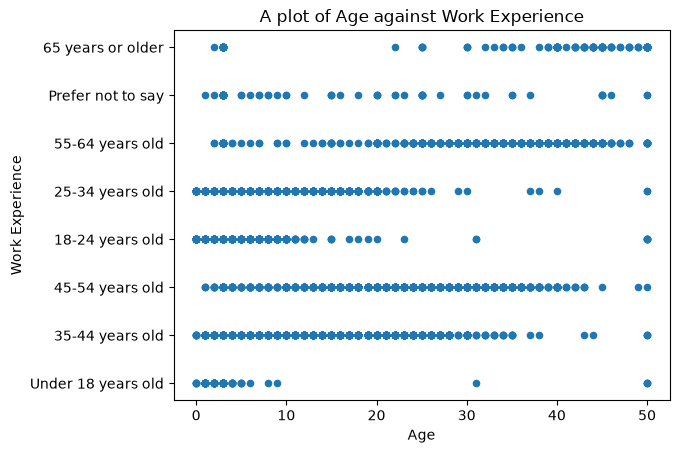

In [43]:
df = df.copy()
mode = df['WorkExp'].mode()[0]
df['WorkExp'] = df['WorkExp'].fillna(mode)

df.plot(kind='scatter', x='WorkExp', y='Age')
plt.title('A plot of Age against Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience')
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


          TimeSearching                                        Frustration
0                   NaN                                                NaN
1                   NaN                                                NaN
2                   NaN                                                NaN
3                   NaN                                                NaN
4                   NaN                                                NaN
5                   NaN                                                NaN
6                   NaN                                                NaN
7                   NaN                                                NaN
8                   NaN                                                NaN
9                   NaN                                                NaN
10  30-60 minutes a day  Amount of technical debt;Number of software to...
11                  NaN                                                NaN
12  30-60 minutes a day  

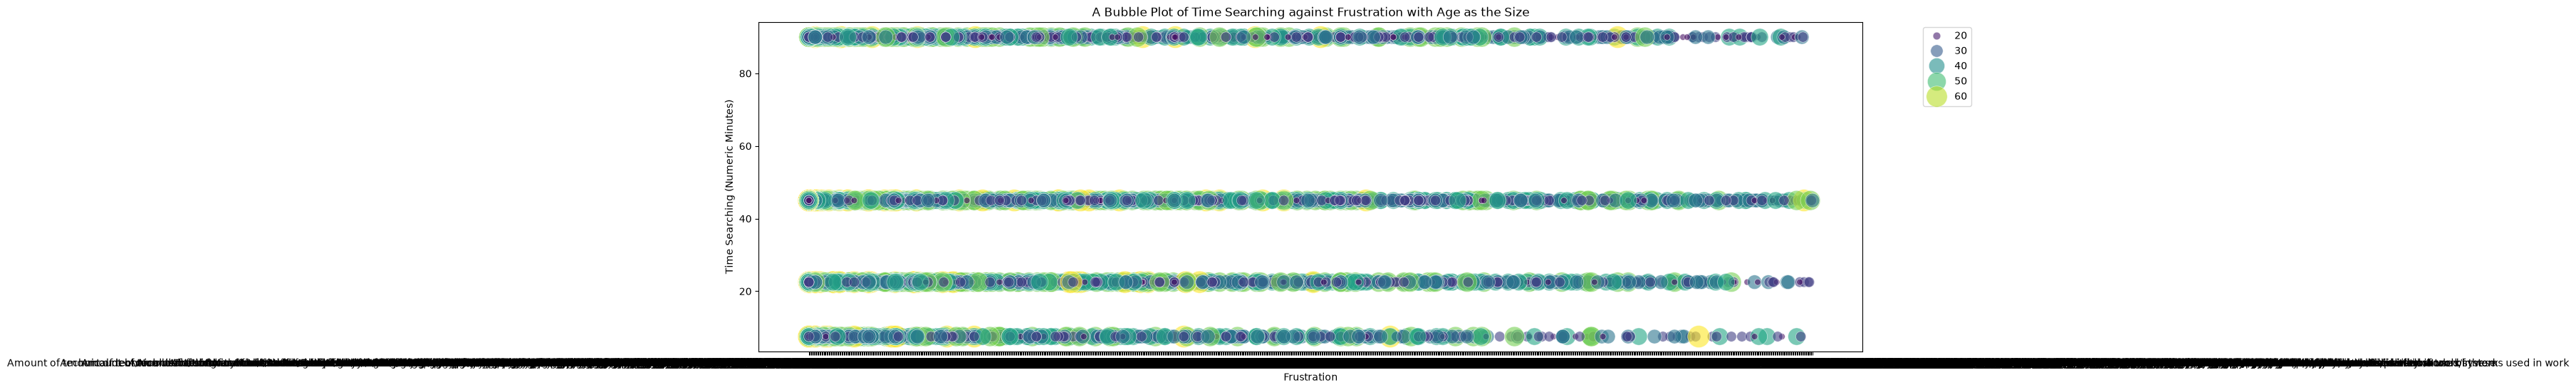

In [83]:
## Write your code here
Query = """
SELECT TimeSearching, Frustration, Age FROM main
"""
df = df = pd.read_sql_query(Query, conn)
print(df[['TimeSearching', 'Frustration']].head(15))

df = df.copy()
mode = df['Age'].mode()[0]
df['Age'] = df['Age'].fillna(mode)

# Extract the first set of digits from the text string
df['Age_Numeric'] = df['Age'].str.extract(r'(\d+)').astype(float)

# Handle the 'Under 18' category manually since its digit is 18, but it means younger
df.loc[df['Age'] == 'Under 18 years old', 'Age_Numeric'] = 16 

df = df.copy()
mode = df['TimeSearching'].mode()[0]
df['TimeSearching'] = df['TimeSearching'].fillna(mode)

df = df.copy()
mode = df['Frustration'].mode()[0]
df['Frustration'] = df['Frustration'].fillna(mode)

time_mapping = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45.0,
    '60-120 minutes a day': 90.0
}

# Apply the mapping to create a clean numeric column
df['TimeSearching_Numeric'] = df['TimeSearching'].map(time_mapping)

# Check the results
print(df[['TimeSearching', 'TimeSearching_Numeric']].iloc[[15, 18, 20]])

plt.figure(figsize=(20, 6))

sns.scatterplot(
    data=df, 
    x='Frustration', 
    y='TimeSearching_Numeric', 
    size='Age_Numeric',      # Controls bubble size (Numerical)     
    hue='Age_Numeric',       # ADDED: Controls bubble color (Numerical or Categorical)
    sizes=(20, 500),         # Sets minimum and maximum bubble sizes
    alpha=0.6,               # Makes bubbles transparent so they don't hide each other
    palette='viridis'        # This will now work beautifully!
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('A Bubble Plot of Time Searching against Frustration with Age as the Size')
plt.xlabel('Frustration')
plt.ylabel('Time Searching (Numeric Minutes)')
plt.show()



### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


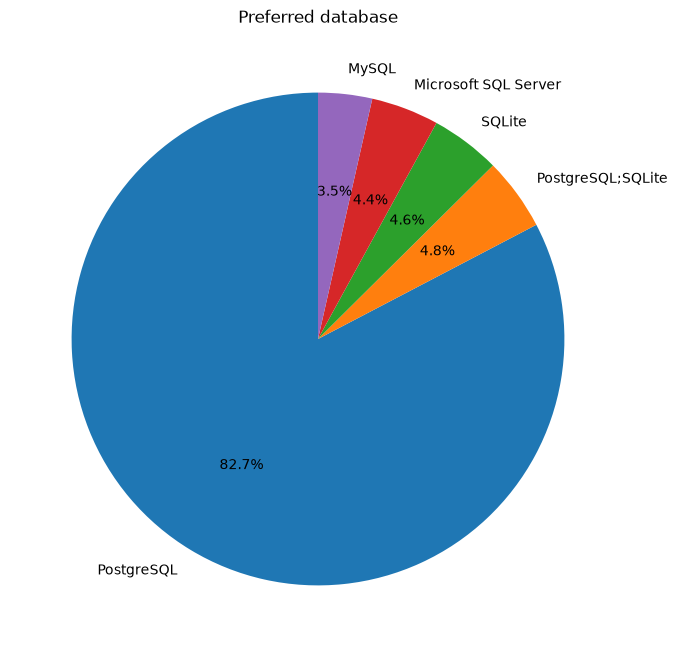

In [82]:
## Write your code here
Query = """
SELECT DatabaseWantToWorkWith as db FROM main
"""
df = df = pd.read_sql_query(Query, conn)

df = df.copy()
mode = df['db'].mode()[0]
df['db'] = df['db'].fillna(mode)

df['db'].value_counts().head().plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(8, 8))

plt.title('Preferred database')
plt.show()


**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


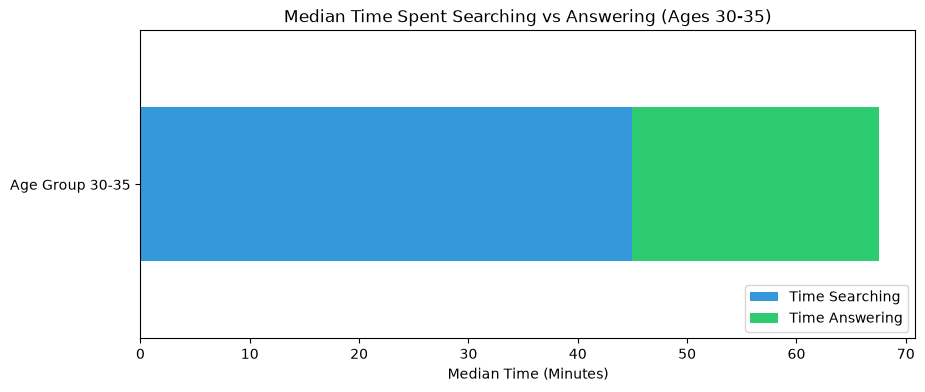

In [86]:
## Write your code here
Query = """
SELECT * FROM main
"""
df = df = pd.read_sql_query(Query, conn)
df = df.copy()
mode = df['TimeSearching'].mode()[0]
df['TimeSearching'] = df['TimeSearching'].fillna(mode)

df = df.copy()
mode = df['TimeAnswering'].mode()[0]
df['TimeAnswering'] = df['TimeAnswering'].fillna(mode)

df = df.copy()
mode = df['Age'].mode()[0]
df['Age'] = df['Age'].fillna(mode)

df['Age_Numeric'] = df['Age'].str.extract(r'(\d+)').astype(float)

df.loc[df['Age'] == 'Under 18 years old', 'Age_Numeric'] = 16 


time_mapping = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45.0,
    '60-120 minutes a day': 90.0
}

# Apply the mapping to create a clean numeric column
df['TimeSearching_Numeric'] = df['TimeSearching'].map(time_mapping)


# 2. Filter the DataFrame for individuals aged 30 to 35
age_filter = df[(df["Age_Numeric"] >= 30) & (df["Age_Numeric"] <= 35)]

# 3. Calculate the median times for this targeted group
medians = pd.DataFrame(
    {
        "Time Searching": [age_filter["TimeSearching_Numeric"].median()],
        "Time Answering": [age_filter["TimeAnswering_Numeric"].median()],
    },
    index=["Age Group 30-35"],
)

# 4. Plot as a stacked horizontal bar chart
medians.plot(kind="barh", stacked=True, color=["#3498db", "#2ecc71"], figsize=(10, 4))

# Adjust layout strings
plt.title("Median Time Spent Searching vs Answering (Ages 30-35)")
plt.xlabel("Median Time (Minutes)")
plt.ylabel("")  # Removes blank placeholder text from the y-axis
plt.legend(loc="lower right")
plt.show()


### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


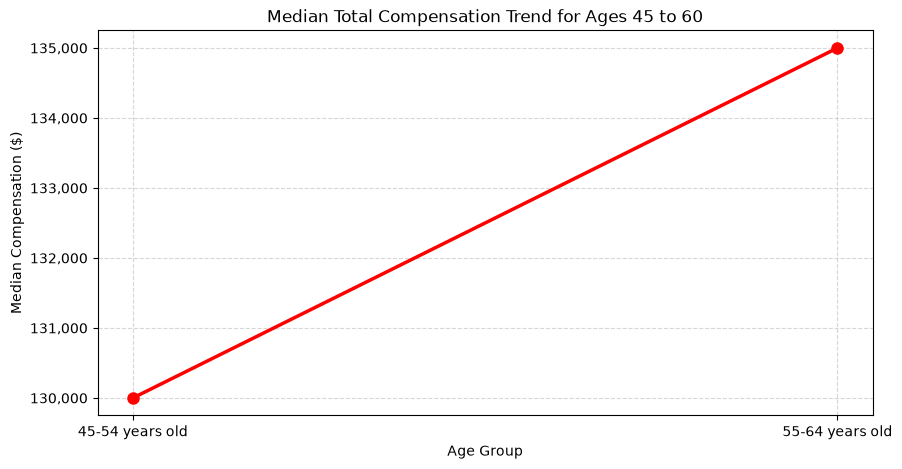

In [89]:
## Write your code here
mode = df['CompTotal'].mode()[0]
df['CompTotal'].fillna(mode)

filtered_df = df[(df["Age_Numeric"] == 45) | (df["Age_Numeric"] == 55)]

age_medians = (
    filtered_df.groupby(["Age", "Age_Numeric"])["CompTotal"]
    .median()
    .reset_index()
    .sort_values("Age_Numeric")
)

plt.figure(figsize=(10, 5))
plt.plot(
    age_medians["Age"],
    age_medians["CompTotal"],
    color="Red",
    marker="o",
    linewidth=2.5,
    markersize=8,
)

plt.title("Median Total Compensation Trend for Ages 45 to 60")
plt.xlabel("Age Group")
plt.ylabel("Median Compensation ($)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))

plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [91]:
## Write your code here
mode = df['MainBranch'].mode()[0]
df['MainBranch'].fillna(mode)

df['MainBranch'].plot(kind='barh')


0    I am a developer by profession
1    I am a developer by profession
2    I am a developer by profession
3             I am learning to code
4    I am a developer by profession
Name: MainBranch, dtype: str

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
